## Zeroshot EnergyTSPulse for Energy Anomaly Detection

This notebook demonstrates **EnergyTSPulse**, a reconstruction-based time-series foundation model pretrained on large-scale energy meter data, for zeroshot anomaly detection. EnergyTSPulse learns rich temporal representations by reconstructing fixed-length input windows (context length `512`), capturing both short-term dynamics and seasonal usage patterns typical in building energy consumption.

For anomaly detection, the model processes non-overlapping windows of length `512`. 
Each window is reconstructed in the time domain (and optionally frequency domain), and the reconstruction error is used as an anomaly score. Windows with unusually high error indicate abnormal energy behavior.

The workflow includes:
- Loading pretrained EnergyTSPulse weights  
- Preparing and normalizing building-level time-series data  
- Reconstructing input windows using the pretrained model  
- Computing reconstruction-based anomaly scores  
- Evaluating detection performance using window-level precision, recall, and F1-score  

This approach leverages pretrained temporal knowledge without training a task-specific anomaly detector from scratch.


<a target="_blank" href="https://colab.research.google.com/github/energyfms/notebooks/blob/main/energy_tspulse_anomaly_detection_zeroshot.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


### Install Granite-TSFM dependencies

In [ ]:
! pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git"

In [1]:

from transformers import AutoConfig
from safetensors.torch import load_file
import os, gc, json, logging
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import KFold
from safetensors.torch import load_file
import matplotlib.pyplot as plt
import seaborn as sns
logging.getLogger("transformers").setLevel(logging.ERROR)
from tsfm_public.models.tspulse import TSPulseForClassification
from tsfm_public.models.tspulse.modeling_tspulse import TSPulseForReconstruction, get_fft


### 📊 Dataset Overview & Exploratory Analysis

In this section, we load the **Energy Anomaly Detection** dataset and perform basic exploratory data analysis (EDA) to understand its structure and characteristics.

We begin by examining dataset dimensions, summary statistics, and anomaly distribution. Missing values in meter readings are handled using **building-wise median imputation**, ensuring robust preprocessing without introducing unrealistic patterns.

Next, we visualize overall energy consumption trends and inspect temporal behavior. Finally, we plot the time series of a sample building and highlight anomaly timestamps to build an intuitive understanding of abnormal energy usage patterns before proceeding to model evaluation.

This analysis is conducted using the **Energy Anomaly Detection Dataset** from Kaggle:  
https://www.kaggle.com/competitions/energy-anomaly-detection

In [ ]:

# Configuration
csv_path = "http://raw.githubusercontent.com/energyfms/notebooks/refs/heads/main/Dataset/AnomalyDetection/sample_building_697_lead.csv"

device = f"cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Device selected: {device}")


[INFO] Device selected: cuda:0


In [3]:
# -------------------------------------------------------
# Load Dataset
# -------------------------------------------------------
df = pd.read_csv(csv_path, parse_dates=["timestamp"])
df.sort_values(["building_id", "timestamp"], inplace=True)

print("\n[INFO] Dataset Loaded")
print("Shape:", df.shape)
print("Unique Buildings:", df["building_id"].nunique())

print("\n[INFO] Missing Values:")
print(df.isna().sum())

df.head()


[INFO] Dataset Loaded
Shape: (1749494, 4)
Unique Buildings: 200

[INFO] Missing Values:
building_id           0
timestamp             0
meter_reading    107653
anomaly               0
dtype: int64


,building_id,timestamp,meter_reading,anomaly
0,1,2016-01-01 00:00:00,NaN,0
200,1,2016-01-01 01:00:00,NaN,0
398,1,2016-01-01 02:00:00,NaN,0
597,1,2016-01-01 03:00:00,NaN,0
796,1,2016-01-01 04:00:00,NaN,0


### Let's Sample one building from this dataset

In [4]:
# Let's Sample one building from this dataset
sample_building = df["building_id"].unique()[65]
sample_df = df[df["building_id"] == sample_building]

<Axes: title={'center': 'Building 680 Energy Consumption'}, xlabel='timestamp'>

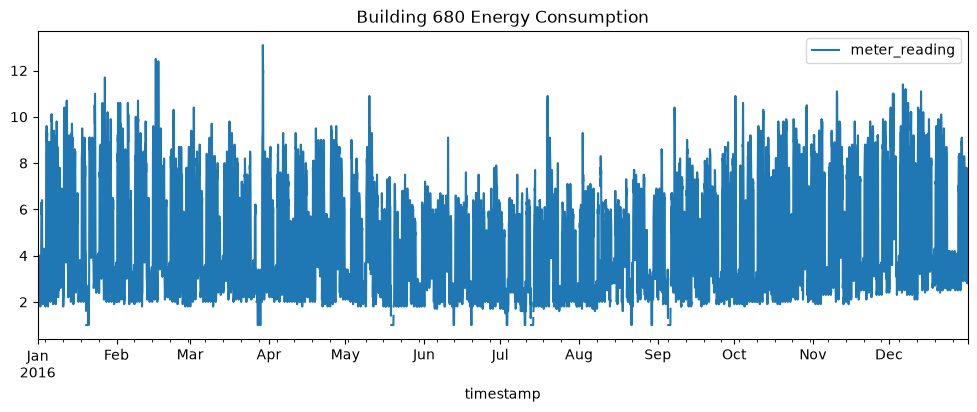

In [5]:
# Visualize the energy consumption pattern for this building
sample_df.plot(x="timestamp", y="meter_reading", figsize=(12, 4), title=f"Building {sample_building} Energy Consumption")

In [ ]:

# Fill Missing Values

sample_df["meter_reading"] = (
    sample_df["meter_reading"]
      .transform(lambda s: s.fillna(s.median()))
)

print("[INFO] Filled missing meter_reading per building using median.")


[INFO] Filled missing meter_reading per building using median.


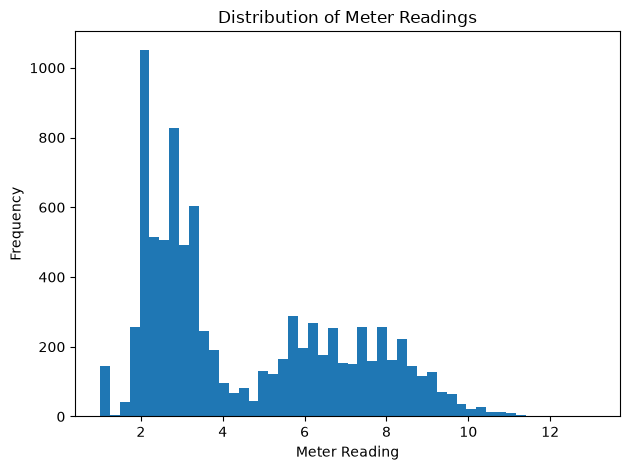

In [ ]:

# Global Distribution

plt.figure()
plt.hist(sample_df["meter_reading"], bins=50)
plt.title("Distribution of Meter Readings")
plt.xlabel("Meter Reading")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



#### Visualsing Anomalies in the Energy Data


[INFO] Visualizing Building 680


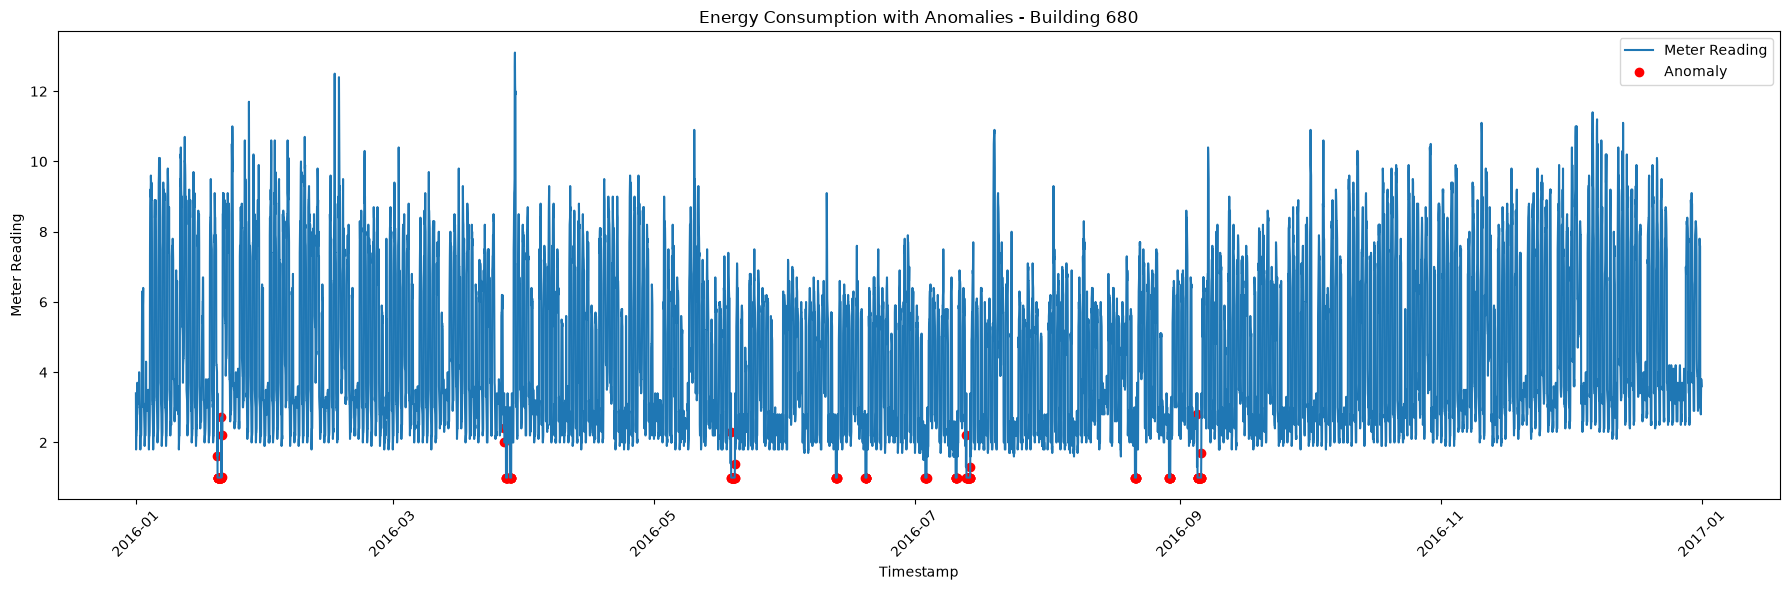

In [ ]:

# Sample Building Visualization (Time Series + Anomalies)


print(f"\n[INFO] Visualizing Building {sample_building}")

plt.figure(figsize=(18, 6))

# Full time-series
plt.plot(
    sample_df["timestamp"],
    sample_df["meter_reading"],
    label="Meter Reading"
)

# Overlay anomalies in red
if "anomaly" in sample_df.columns:
    anomalies = sample_df[sample_df["anomaly"] == 1]
    plt.scatter(
        anomalies["timestamp"],
        anomalies["meter_reading"],
        color="red",
        label="Anomaly"
    )

plt.title(f"Energy Consumption with Anomalies - Building {sample_building}")
plt.xlabel("Timestamp")
plt.ylabel("Meter Reading")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Baseline Model for Anomaly detection 

#### Visualize the anomaly class distribution

INFO:p-1921529:t-140681770833728:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:p-1921529:t-140681770833728:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


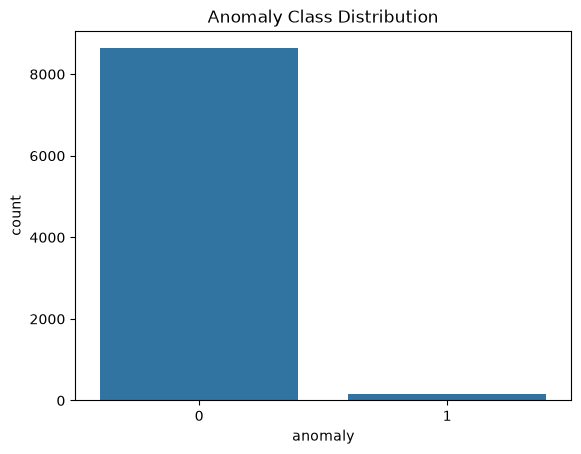

anomaly
0    0.978682
1    0.021318
Name: proportion, dtype: float64


In [9]:

sns.countplot(x=sample_df["anomaly"])
plt.title("Anomaly Class Distribution")
plt.show()

print(df["anomaly"].value_counts(normalize=True))


#### Splitting the Dataset into train and test
We will use the first half of the time-series for training and the second half for testing to maintain temporal integrity.

In [10]:

split_idx = len(sample_df) // 2

train_df = sample_df.iloc[:split_idx].copy()
test_df  = sample_df.iloc[split_idx:].copy()

print("Train range:", train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Test range :", test_df["timestamp"].min(),  "→", test_df["timestamp"].max())


Train range: 2016-01-01 00:00:00 → 2016-07-01 23:00:00
Test range : 2016-07-02 00:00:00 → 2016-12-31 23:00:00


In [11]:
# Train anomaly percentage
train_anom_pct = 100 * train_df["anomaly"].mean()

# Test anomaly percentage
test_anom_pct = 100 * test_df["anomaly"].mean()

print(f"Train anomaly percentage: {train_anom_pct:.2f}%")
print(f"Test anomaly percentage : {test_anom_pct:.2f}%")


Train anomaly percentage: 1.80%
Test anomaly percentage : 1.73%


### InterQuartile Range  (IQR)

In [12]:
Q1 = train_df["meter_reading"].quantile(0.25)
Q3 = train_df["meter_reading"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)


Lower bound: -3.5
Upper bound: 12.5


In [13]:
test_df["iqr_pred"] = (
    (test_df["meter_reading"] < lower_bound) |
    (test_df["meter_reading"] > upper_bound)
).astype(int)


### Modified Z Score

In [14]:
median = train_df["meter_reading"].median()
mad = np.median(np.abs(train_df["meter_reading"] - median))

print("Median:", median)
print("MAD:", mad)

mz_scores = 0.6745 * (test_df["meter_reading"] - median) / (mad + 1e-8)

test_df["mz_pred"] = (np.abs(mz_scores) > 3.5).astype(int)



Median: 3.4
MAD: 1.4


### Evaluation Method

We compute the anomaly detection metric for each window of `24hrs` (1 day) rather than pointwise.

In [15]:
def calc_window_metrics(y_true, y_pred, window_size):
    """
    Computes window-wise anomaly classification metrics.
    A window is anomalous if it contains ANY anomaly.
    """

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    n_blocks = len(y_true) // window_size
    TP, FP, FN = 0, 0, 0

    for i in range(n_blocks):
        s, e = i * window_size, (i + 1) * window_size

        true_any = y_true[s:e].any()
        pred_any = y_pred[s:e].any()

        if true_any and pred_any:
            TP += 1
        elif not true_any and pred_any:
            FP += 1
        elif true_any and not pred_any:
            FN += 1

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1


In [16]:
# Evaluate IQR Method

y_true = test_df["anomaly"].values
y_pred = test_df["iqr_pred"].values
window_size = 24

prec_w, rec_w, f1_w = calc_window_metrics(
    y_true,
    y_pred,
    window_size
)
print("Anomaly Detection Metrics (IQR Method):")
print(f"Window Precision: {prec_w:.4f}")
print(f"Window Recall   : {rec_w:.4f}")
print(f"Window F1       : {f1_w:.4f}")


Anomaly Detection Metrics (IQR Method):
Window Precision: 0.0000
Window Recall   : 0.0000
Window F1       : 0.0000


In [17]:
# Evaluate MZ Method
y_pred_mz = test_df["mz_pred"].values

prec_w, rec_w, f1_w = calc_window_metrics(
    y_true,
    y_pred_mz,
    window_size
)
print("Anomaly Detection Metrics (MZ Method):")
print(f"[MZ] Window Precision: {prec_w:.4f}")
print(f"[MZ] Window Recall   : {rec_w:.4f}")
print(f"[MZ] Window F1       : {f1_w:.4f}")


Anomaly Detection Metrics (MZ Method):
[MZ] Window Precision: 0.0000
[MZ] Window Recall   : 0.0000
[MZ] Window F1       : 0.0000


## Loading EnergyTSPulse for Anomaly Detection

Energy TSPulse can be loaded directly from huggingface. 

In [ ]:
model = TSPulseForReconstruction.from_pretrained(
    "EnergyFM/energy-tspulse",
    revision="512-comm", #model revision: 512-comm, 512-res
    num_input_channels=1
).to(device)



context_length = 512

## Zero-Shot Anomaly Detection Pipeline for EnergyTSPulse 

### Pre-Processing
For each building, the time series is normalized, segmented into fixed-length windows

In [19]:
def normalize_series(x):
    """
    Z-score normalize a 1D time series.
    """
    mu = x.mean()
    sd = x.std()

    if sd < 1e-8:
        return None, None, None

    xn = (x - mu) / sd
    return xn, mu, sd


In [20]:
def pad_series(x, y, window_size):
    """
    Pad series so length is divisible by window_size.
    """
    n = len(x)
    pad = (-n) % window_size

    if pad > 0:
        x = np.concatenate([x, np.zeros(pad, dtype=np.float32)])
        y = np.concatenate([y, np.zeros(pad, dtype=int)])

    return x, y


In [21]:
# Extract series
x = test_df["meter_reading"].to_numpy(np.float32)
y = test_df["anomaly"].to_numpy(int)
n = len(x)

if n < context_length:
    raise ValueError("Test series shorter than context length.")

# Normalize
xn, mu, sd = normalize_series(x)
if xn is None:
    raise ValueError("Series variance too small.")

# Pad
xn, y = pad_series(xn, y, context_length)

An anomaly score is computed per window by combining:
- **Time-domain reconstruction error**
- **Frequency-domain (FFT) reconstruction error**

A threshold is automatically selected to maximize window-level F1-score. Final metrics (precision, recall, F1) are computed at the window level and aggregated per building.

In [22]:
def compute_window_scores(model, xn, context_length, device, fft_weight=0.5):
    """
    Compute anomaly score per non-overlapping window.
    """
    model.eval()
    scores = []

    for i in range(0, len(xn), context_length):

        window = xn[i:i+context_length]

        t = torch.tensor(window, device=device).view(1, context_length, 1)
        mask = torch.ones_like(t, dtype=torch.bool)

        with torch.no_grad():
            out = model(past_values=t, past_observed_mask=mask)

        # Time-domain reconstruction error
        rec = out.reconstruction_outputs.view(-1).cpu().numpy()
        se_time = ((rec - window) ** 2).max()

        # Frequency-domain error
        fft_true, *_ = get_fft(t)
        fft_rec = out.reconstruction_outputs
        se_freq = ((fft_rec - fft_true) ** 2).max().item()

        scores.append(se_time + fft_weight * se_freq)

    return np.array(scores, dtype=np.float32)


In [23]:
def find_best_threshold(scores, y_true, window_size):
    """
    Searches threshold to maximize window F1.
    Only scans over scores from normal windows to ignore extreme outliers.
    """
    best_f1, best_th = -1, 0

    y_win = y_true.reshape(-1, window_size)
    normal_scores = scores[~y_win.any(axis=1)]

    if len(normal_scores) < 2:
        lo, hi = scores.min(), scores.max()
    else:
        lo, hi = normal_scores.min(), normal_scores.max()

    if hi <= lo:
        hi = lo + 1e-6

    for th in np.linspace(lo, hi, 100):
        block_pred = (scores > th).astype(int)
        y_pred = np.repeat(block_pred, window_size)
        _, _, f1 = calc_window_metrics(y_win.reshape(-1), y_pred[:len(y_true)], window_size)
        if f1 > best_f1:
            best_f1, best_th = f1, th

    return best_th


In [24]:

# Compute window anomaly scores
scores = compute_window_scores( model,
    xn,  context_length, device, fft_weight=0.5 )

# Find threshold
th = find_best_threshold( scores, y[:len(scores) * context_length], context_length)

# Window-level predictions
window_preds = (scores > th).astype(int)

In [25]:
def expand_window_predictions(window_preds, context_length, original_length):
    """
    Expand window-level predictions to timestep-level.
    """
    y_pred = np.repeat(window_preds, context_length)
    return y_pred[:original_length]


### Evaluating EnergyTSPulse for Anomaly Detection

In [26]:
# Expand to timestep-level
y_pred = expand_window_predictions(
    window_preds,
    context_length,
    n
)

# Window-level metrics
wp, wr, wf = calc_window_metrics( y[:n], y_pred, context_length )
print("Anomaly Detection Metrics (Energy TSPulse Reconstruction):")
print(f"Window Precision: {wp:.4f}")
print(f"Window Recall   : {wr:.4f}")   
print(f"Window F1       : {wf:.4f}")

Anomaly Detection Metrics (Energy TSPulse Reconstruction):
Window Precision: 0.3333
Window Recall   : 0.6667
Window F1       : 0.4444
